# Backtest runner

Downloads the market data if it is missing or covers the wrong period, then runs
the strategy with the parameters from `test/backtest/.env` and sweeps one
parameter at a time.

In [1]:
import csv, datetime, json, os, subprocess
from pathlib import Path

ROOT = Path.cwd().parents[1] if Path.cwd().name == 'analytics' else Path.cwd()
DATA = ROOT / 'test' / 'data'
SWAPS, CANDLES = DATA / 'pool_swaps.csv', DATA / 'binance_candles.csv'

def read_env(path):
    out = {}
    for line in path.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith('#'):
            k, _, v = line.partition('=')
            out[k.strip()] = v.strip()
    return out

def run(cmd, cwd):
    p = subprocess.run(cmd, cwd=cwd, shell=True, capture_output=True, text=True)
    print(p.stdout or p.stderr)
    return p.returncode

print('project:', ROOT)

project: /Users/kuzalex/CMF/uniswapV3MarketMakingBot


## 1. Data

In [2]:
def covered_days(path):
    """First and last UTC date present in a CSV, or None if it is missing."""
    if not path.exists():
        return None
    rows = list(csv.DictReader(path.open()))
    if not rows:
        return None
    day = lambda r: datetime.datetime.fromtimestamp(int(r['timestamp']), datetime.UTC).date()
    return day(rows[0]), day(rows[-1])

wanted = read_env(DATA / '.env')
start = datetime.date.fromisoformat(wanted['START_DAY'])
end = datetime.date.fromisoformat(wanted['END_DAY'])

have = covered_days(SWAPS), covered_days(CANDLES)
fresh = all(h == (start, end) for h in have)

print(f'wanted   {start} .. {end}')
print(f'swaps    {have[0]}')
print(f'candles  {have[1]}')
print('up to date' if fresh else 'needs download')

wanted   2026-08-01 .. 2026-08-07
swaps    (datetime.date(2026, 8, 1), datetime.date(2026, 8, 7))
candles  (datetime.date(2026, 8, 1), datetime.date(2026, 8, 7))
up to date


In [3]:
# Downloading a week takes a few minutes: the public node is rate limited and
# the script backs off on 429.
if fresh:
    print('skipped, data already covers the period')
else:
    run('python3 download.py', cwd=DATA)

skipped, data already covers the period


In [4]:
run('npm run backtest --silent', cwd=ROOT)

params          spread 30, width 10, pull 0.95, band 100

swaps           112,279, touched our quotes 60
  inward            41  68%   sold dearer / bought cheaper
  back              19  32%   bought back what we sold, same prices
fees            $19.11
gas             $18.17   (518 burns + 520 mints)
total PnL       $138.40   actual money, direction included
delta-hedged    $17.35   what the strategy earned, direction removed
hedge           $0.00   (0 swaps on $0)

redeploys       275
  Binance moved        265  96%
  pool retraced          9  3%
  no quotes up           1  0%

wallet before   2.0000 WETH + 5000.00 USDC  =  $8721.65  at $1860.82
wallet after    1.0436 WETH + 6861.85 USDC  =  $8859.11  at $1913.76



0

## 3. One parameter at a time

Each sweep changes a single parameter and leaves the rest at their `.env` values,
so every curve answers one question on its own.

In [5]:
# The backtest speaks JSON when asked, so nothing here parses prose.
def backtest(**overrides):
    env = {**os.environ, 'REPORT': 'json', **{k: str(v) for k, v in overrides.items()}}
    out = subprocess.run('npm run backtest --silent', cwd=ROOT, shell=True,
                         capture_output=True, text=True, env=env).stdout
    r = json.loads(out)
    fills = r['swaps']['inward'] + r['swaps']['back']
    return {
        'fees': r['fees'],
        'gas': r['gas'],
        'net': r['net'],
        # What the strategy earned with the price move on our own exposure
        # taken out. The only column comparable between runs: everything else
        # carries whichever way ETH happened to go.
        'hedgedPnl': r['hedgedPnl'],
        'totalPnl': r['totalPnl'],
        'inward': r['swaps']['inward'],
        'back': r['swaps']['back'],
        # Share of fills that went deeper into the quote rather than
        # walking back out. A round trip gives the spread back, so the
        # higher this is, the more of each fill we actually keep.
        'inwardPct': 100 * r['swaps']['inward'] / fills if fills else float('nan'),
        'touched': r['swaps']['touched'],
        'redeploys': r['redeploys']['total'],
        'byRetrace': r['redeploys']['poolRetraced'],
        'hedges': r['hedges']['count'],
        'hedgeCost': r['hedges']['costUsd'],
        'valueUsd': r['wallet']['after']['valueUsd'],
        # Where the wallet ended up. Without rebalancing it is whatever the
        # market left us holding, which is a directional bet none of the money
        # columns price. Runs that drifted are not comparable to ones that held.
        'ethShare': 100 * r['wallet']['after']['weth'] * r['wallet']['after']['price']
                    / r['wallet']['after']['valueUsd'],
        'vsHodl': r['wallet']['after']['valueUsd'] + r['net'] - r['hodlUsd'],
    }

def sweep(name, values):
    return values, [backtest(**{name: v}) for v in values]

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

RESULTS = Path.cwd() / 'results'
RESULTS.mkdir(exist_ok=True)

def plot(name, values, rows, keys=('fees', 'gas'), title='-', ylabel='USD'):
    """One axis only: pass keys that share units."""
    plt.figure(figsize=(6, 3.2))
    for key in keys:
        plt.plot(values, [r[key] for r in rows], linewidth=1, marker='.', label=key)
    plt.xlabel(name)
    plt.ylabel(ylabel)
    plt.title(title)
    if len(keys) > 1:
        plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

def table(name, values, rows):
    """Saves the sweep to results/<name>.csv and returns it for display."""
    df = pd.DataFrame(rows).round(2)
    df.insert(0, name, values)
    df.to_csv(RESULTS / f'{name}.csv', index=False)
    return df

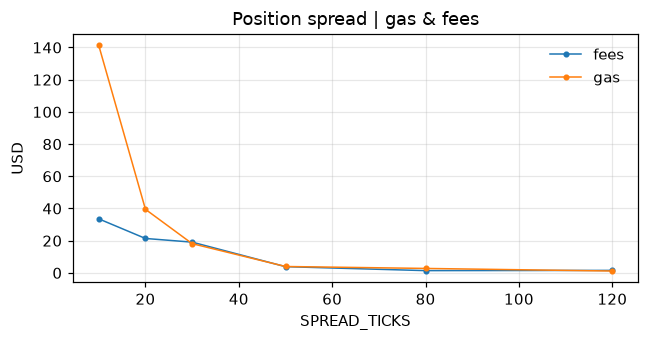

In [7]:
values, rows = sweep('SPREAD_TICKS', [10, 20, 30, 50, 80, 120])
plot('SPREAD_TICKS', values, rows, title = 'Position spread | gas & fees')
# plot('SPREAD_TICKS', values, rows, keys=('inwardPct',), title = 'Position spread | non-arbitrage fills', ylabel = '% of fills')

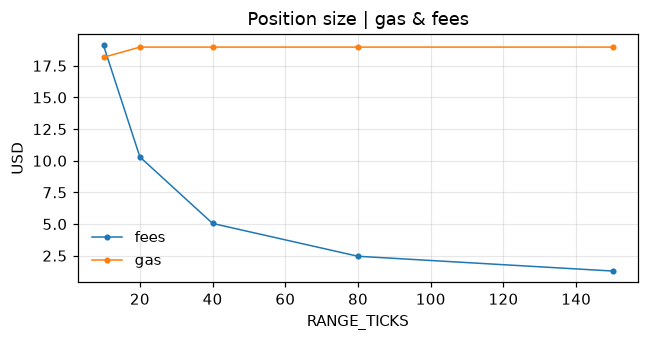

In [8]:
values, rows = sweep('RANGE_TICKS', [10, 20, 40, 80, 150])
plot('RANGE_TICKS', values, rows, title = 'Position size | gas & fees')

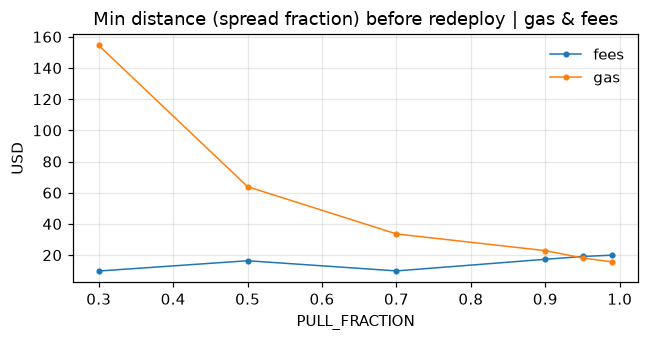

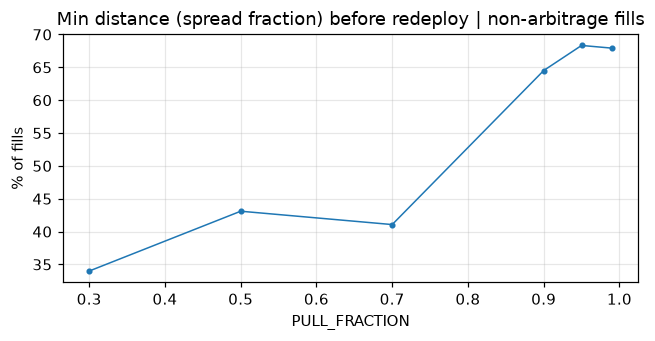

In [9]:
values, rows = sweep('PULL_FRACTION', [0.3, 0.5, 0.7, 0.9, 0.95, 0.99])
plot('PULL_FRACTION', values, rows, title = 'Min distance (spread fraction) before redeploy | gas & fees')
plot('PULL_FRACTION', values, rows, keys=('inwardPct',), title = 'Min distance (spread fraction) before redeploy | non-arbitrage fills', ylabel = '% of fills')

## 4. Brute force over the whole grid

Every combination is run, so nothing is assumed about how the parameters interact.
One run takes about four seconds and holds 570 MB, so a few of them go at once.

In [10]:
import itertools
from concurrent.futures import ThreadPoolExecutor

GRID = {
    'SPREAD_TICKS': [20, 30, 50, 80],
    'RANGE_TICKS': [10, 20, 40],
    'PULL_FRACTION': [0.7, 0.9, 0.95, 0.99],
    'POOL_ARBITRAGE_TRIGGER': [2, 5, 20],
    'HEDGE_BAND': [10, 20, 100],
}

def search(grid, workers=6):
    """Runs every combination and saves the whole grid to results/search.csv."""
    names = list(grid)
    combos = [dict(zip(names, values)) for values in itertools.product(*grid.values())]
    with ThreadPoolExecutor(workers) as pool:
        rows = list(pool.map(lambda combo: {**combo, **backtest(**combo)}, combos))
    frame = pd.DataFrame(rows).round(2)
    frame.to_csv(RESULTS / 'search.csv', index=False)
    return frame

grid = search(GRID)
print(f'{len(grid)} combinations, {len(GRID)} parameters')

432 combinations, 5 parameters


In [11]:
COLUMNS = [*GRID, 'fees', 'gas', 'hedgeCost', 'hedgedPnl', 'totalPnl', 'redeploys', 'ethShare']
best = lambda frame: frame.sort_values('hedgedPnl', ascending=False).head(8)[COLUMNS]

# Ranked by hedgedPnl, not by totalPnl: total money is dominated by where ETH
# happened to go, and the runs end with wildly different exposure to it.
# Turning rebalancing off (HEDGE_BAND 100) saves its cost and still shows up
# well here, so the second table keeps only runs that actually rebalance.
print('all 432 combinations')
display(best(grid))
print('only the ones that rebalance')
display(best(grid[grid.HEDGE_BAND != 100]))

all 432 combinations


,SPREAD_TICKS,RANGE_TICKS,PULL_FRACTION,POOL_ARBITRAGE_TRIGGER,HEDGE_BAND,fees,gas,hedgeCost,hedgedPnl,totalPnl,redeploys,ethShare
125,30,10,0.90,20,100,20.10,21.14,0.00,47.16,174.27,311,33.15
119,30,10,0.90,2,100,20.04,21.92,0.00,45.33,169.52,322,11.44
122,30,10,0.90,5,100,20.36,21.92,0.00,45.04,168.03,322,20.31
123,30,10,0.90,20,10,22.19,21.74,3.07,42.99,132.93,311,49.94
142,30,10,0.99,20,20,30.74,16.98,4.54,42.79,130.72,243,51.03
141,30,10,0.99,20,10,30.74,16.98,4.54,42.79,130.72,243,51.03
134,30,10,0.95,20,100,24.35,18.48,0.00,42.26,189.14,271,25.33
120,30,10,0.90,5,10,21.31,22.51,2.20,41.10,144.87,322,50.00


only the ones that rebalance


,SPREAD_TICKS,RANGE_TICKS,PULL_FRACTION,POOL_ARBITRAGE_TRIGGER,HEDGE_BAND,fees,gas,hedgeCost,hedgedPnl,totalPnl,redeploys,ethShare
123,30,10,0.90,20,10,22.19,21.74,3.07,42.99,132.93,311,49.94
142,30,10,0.99,20,20,30.74,16.98,4.54,42.79,130.72,243,51.03
141,30,10,0.99,20,10,30.74,16.98,4.54,42.79,130.72,243,51.03
120,30,10,0.90,5,10,21.31,22.51,2.20,41.10,144.87,322,50.00
124,30,10,0.90,20,20,21.50,21.74,2.83,39.20,131.73,311,50.01
121,30,10,0.90,5,20,20.75,22.51,1.45,37.30,166.92,322,38.10
18,20,10,0.95,2,10,26.84,41.24,5.17,34.70,98.57,590,50.00
117,30,10,0.90,2,10,18.44,22.72,2.14,34.51,142.87,325,50.00
